# EDGAR Credit Clustering Starter v3 — Rating-Style Risk-Factor Clustering

This version pivots from **financial profile clustering** toward **credit rating-style risk-factor clustering**.

Core framing:

- The model is still unsupervised: no external rating/default labels are used.
- The feature engineering is now directional: higher engineered values mean higher credit risk.
- The five clusters are intended to behave more like broad credit-risk buckets.
- Absolute company size is **not** used as a clustering feature by default.
- Absolute values are used only for:
  - data-quality filters,
  - size/materiality flags,
  - analyst diagnostics.

Important distinction:

- `cluster` = risk-factor bucket discovered by KMeans.
- `rating_style_label` = post-cluster interpretation based on median risk score.
- This is not a formal credit rating because we do not yet have rating/default labels.


In [33]:
import os
import glob
import duckdb
import numpy as np
import pandas as pd

from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

from pathlib import Path
import sys
import joblib

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

In [60]:
DB_PATH = "financials.duckdb"
BASE_URL = "https://pub-a6c3a3e1a0f546beb4be7cc34fd647d1.r2.dev/raw_financial_facts_parquet"
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR = OUTPUT_DIR / "saved_models"
MODEL_DIR.mkdir(exist_ok=True)

## 1. Connect to DuckDB

The project reads public EDGAR-derived Parquet files from Cloudflare R2.

No credentials are required.

Remote dataset:
https://pub-a6c3a3e1a0f546beb4be7cc34fd647d1.r2.dev/raw_financial_facts_parquet/

The dataset is split into 401 Parquet files named part_00000.parquet through part_00400.parquet.

Expected local inputs from the previous notebook:

- `financials.duckdb`
- `raw_financial_facts_parquet/*.parquet`
- optionally `03_fundamental_universe_ticker_sic_industry.csv`

In [35]:
parquet_urls = [
    f"{BASE_URL}/part_{i:05d}.parquet"
    for i in range(401)
]

con = duckdb.connect(DB_PATH)

con.execute("""
INSTALL httpfs;
LOAD httpfs;
""")

con.execute(f"""
CREATE OR REPLACE VIEW raw_facts AS
SELECT *
FROM read_parquet({parquet_urls})
""")

schema = con.execute("DESCRIBE raw_facts").df()
schema

,column_name,column_type,null,key,default,extra
0,concept,VARCHAR,YES,None,None,None
1,label,VARCHAR,YES,None,None,None
2,value,DOUBLE,YES,None,None,None
3,numeric_value,DOUBLE,YES,None,None,None
4,unit,VARCHAR,YES,None,None,None
5,period_type,VARCHAR,YES,None,None,None
6,period_start,VARCHAR,YES,None,None,None
7,period_end,VARCHAR,YES,None,None,None
8,fiscal_year,BIGINT,YES,None,None,None
9,fiscal_period,VARCHAR,YES,None,None,None


In [7]:
summary = con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT(DISTINCT ticker) AS tickers,
    COUNT(DISTINCT concept) AS concepts,
    MIN(fiscal_year) AS min_year,
    MAX(fiscal_year) AS max_year
FROM raw_facts
""").df()
summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,tickers,concepts,min_year,max_year
0,100149899,8194,13256,0,44012


## 2. Sector mapping

The first notebook used SIC major divisions. For clustering, we keep that, but also create a simpler `financial_flag` because financial companies need separate treatment.

In [36]:
def map_sic_major_division(sic):
    if pd.isna(sic):
        return "Unknown"
    try:
        sic = int(float(sic))
    except Exception:
        return "Unknown"

    if 100 <= sic < 1000:
        return "Agriculture"
    if 1000 <= sic < 1500:
        return "Mining / Energy"
    if 1500 <= sic < 1800:
        return "Construction"
    if 2000 <= sic < 4000:
        return "Manufacturing / Industrials"
    if 4000 <= sic < 5000:
        return "Transportation / Utilities"
    if 5000 <= sic < 6000:
        return "Wholesale / Retail"
    if 6000 <= sic < 6800:
        return "Finance / Insurance / Real Estate"
    if 7000 <= sic < 9000:
        return "Services"
    if 9100 <= sic < 9730:
        return "Public Administration"
    return "Other"

def map_financial_flag(sic):
    if pd.isna(sic):
        return "Unknown"
    try:
        sic = int(float(sic))
    except Exception:
        return "Unknown"
    return "Financial" if 6000 <= sic < 6800 else "Non-financial"

In [37]:
# Optional enriched universe from the first notebook.
if os.path.exists("UNIVERSE_CSV"):
    universe = pd.read_csv("UNIVERSE_CSV")
    universe["major_sector"] = universe.get("industry", universe["sic"].apply(map_sic_major_division))
    universe["financial_flag"] = universe["sic"].apply(map_financial_flag)
    universe = universe[[c for c in ["ticker", "cik", "name", "sic", "Industry Title", "major_sector", "financial_flag"] if c in universe.columns]].drop_duplicates()
else:
    universe = con.execute("""
    SELECT DISTINCT ticker, cik, company_name AS name, sic
    FROM raw_facts
    WHERE ticker IS NOT NULL
    """).df()
    universe["major_sector"] = universe["sic"].apply(map_sic_major_division)
    universe["financial_flag"] = universe["sic"].apply(map_financial_flag)

universe["major_sector"].value_counts(dropna=False).to_frame("companies")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,companies
major_sector,
Manufacturing / Industrials,2870
Finance / Insurance / Real Estate,1978
Services,1553
Transportation / Utilities,702
Wholesale / Retail,483
Mining / Energy,460
Construction,96
Agriculture,52


In [11]:
universe["financial_flag"].value_counts(dropna=False).to_frame("companies")

,companies
financial_flag,
Non-financial,6216
Financial,1978


## 3. Concept map

EDGAR concepts are noisy. We map multiple possible GAAP concepts into canonical feature names. The query below keeps only target concepts, then aggregates issuer-year-canonical-feature values.

For the first pass, we use **FY periods only** and clean fiscal years to 2020–2025.

In [38]:
CONCEPT_MAP = {
    # Balance sheet
    "assets": ["us-gaap:Assets"],
    "assets_current": ["us-gaap:AssetsCurrent"],
    "liabilities": ["us-gaap:Liabilities"],
    "liabilities_current": ["us-gaap:LiabilitiesCurrent"],
    "cash": [
        "us-gaap:CashAndCashEquivalentsAtCarryingValue",
        "us-gaap:CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents",
        "us-gaap:CashAndDueFromBanks",
    ],
    "receivables": ["us-gaap:AccountsReceivableNetCurrent"],
    "inventory": ["us-gaap:InventoryNet"],
    "ppe": ["us-gaap:PropertyPlantAndEquipmentNet"],
    "goodwill": ["us-gaap:Goodwill"],
    "equity": [
        "us-gaap:StockholdersEquity",
        "us-gaap:StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest",
    ],
    "long_term_debt": ["us-gaap:LongTermDebt", "us-gaap:LongTermDebtNoncurrent"],
    "short_term_debt": [
        "us-gaap:ShortTermBorrowings",
        "us-gaap:LongTermDebtCurrent",
        "us-gaap:CurrentPortionOfLongTermDebt",
    ],

    # Income statement
    "revenue": [
        "us-gaap:Revenues",
        "us-gaap:SalesRevenueNet",
        "us-gaap:RevenueFromContractWithCustomerExcludingAssessedTax",
    ],
    "depreciation_amortization": [
    "us-gaap:DepreciationDepletionAndAmortization",
    "us-gaap:DepreciationDepletionAndAmortizationExpense",
    "us-gaap:DepreciationAndAmortization",
    "us-gaap:Depreciation",
    "us-gaap:AmortizationOfIntangibleAssets",
    ],
    "gross_profit": ["us-gaap:GrossProfit"],
    "operating_income": ["us-gaap:OperatingIncomeLoss"],
    "net_income": ["us-gaap:NetIncomeLoss", "us-gaap:ProfitLoss"],
    "interest_expense": ["us-gaap:InterestExpense", "us-gaap:InterestExpenseNonOperating"],
    "sga": ["us-gaap:SellingGeneralAndAdministrativeExpense"],
    "rd": ["us-gaap:ResearchAndDevelopmentExpense"],

    # Cash flow
    "cfo": ["us-gaap:NetCashProvidedByUsedInOperatingActivities"],
    "capex": ["us-gaap:PaymentsToAcquirePropertyPlantAndEquipment"],
}

concept_lookup = []
for canonical, concepts in CONCEPT_MAP.items():
    for concept in concepts:
        concept_lookup.append({"canonical_feature": canonical, "concept": concept})
concept_lookup = pd.DataFrame(concept_lookup)
concept_lookup.head(20)

,canonical_feature,concept
0,assets,us-gaap:Assets
1,assets_current,us-gaap:AssetsCurrent
2,liabilities,us-gaap:Liabilities
3,liabilities_current,us-gaap:LiabilitiesCurrent
4,cash,us-gaap:CashAndCashEquivalentsAtCarryingValue
5,cash,us-gaap:CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents
6,cash,us-gaap:CashAndDueFromBanks
7,receivables,us-gaap:AccountsReceivableNetCurrent
8,inventory,us-gaap:InventoryNet
9,ppe,us-gaap:PropertyPlantAndEquipmentNet


In [39]:
con.register("concept_lookup", concept_lookup)

# Detect the numeric column used in your raw facts export.
cols = set(schema["column_name"].str.lower())
if "numeric_value" in cols:
    value_col = "numeric_value"
elif "value" in cols:
    value_col = "value"
else:
    raise ValueError("Could not find numeric_value or value column in raw_facts.")

# Pick a filing/period sort column if available. This improves deduplication.
schema_cols = schema["column_name"].tolist()
lower_to_actual = {c.lower(): c for c in schema_cols}
sort_candidates = ["filing_date", "filed", "period_end", "end", "start"]
sort_col = next((lower_to_actual[c] for c in sort_candidates if c in lower_to_actual), None)
print("value_col:", value_col, "| sort_col:", sort_col)

value_col: numeric_value | sort_col: period_end


In [40]:
# We aggregate by median to reduce duplicate filing/noisy restatement impact.
# Later: replace this with a stricter latest-filing selection if the raw columns support it.
con.execute(f"""
CREATE OR REPLACE TABLE issuer_year_facts AS
SELECT
    rf.ticker,
    TRY_CAST(rf.cik AS VARCHAR) AS cik,
    ANY_VALUE(rf.company_name) AS company_name,
    TRY_CAST(rf.sic AS INTEGER) AS sic,
    TRY_CAST(rf.fiscal_year AS INTEGER) AS fiscal_year,
    cl.canonical_feature,
    MEDIAN(TRY_CAST(rf.{value_col} AS DOUBLE)) AS value
FROM raw_facts rf
JOIN concept_lookup cl
    ON rf.concept = cl.concept
WHERE TRY_CAST(rf.fiscal_year AS INTEGER) BETWEEN 2020 AND 2025
  AND rf.fiscal_period = 'FY'
  AND TRY_CAST(rf.{value_col} AS DOUBLE) IS NOT NULL
GROUP BY 1,2,4,5,6
""")

facts_summary = con.execute("""
SELECT
    canonical_feature,
    COUNT(*) AS row_count,
    COUNT(DISTINCT ticker) AS ticker_count
FROM issuer_year_facts
GROUP BY canonical_feature
ORDER BY ticker_count DESC
""").df()

facts_summary

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,canonical_feature,row_count,ticker_count
0,net_income,36055,7171
1,assets,36044,7147
2,cfo,35527,7106
3,equity,35594,7048
4,cash,34942,7035
5,depreciation_amortization,31723,6491
6,liabilities,31638,6462
7,revenue,27296,5841
8,operating_income,27902,5778
9,ppe,26720,5771


## 4. Build issuer-year panel

One row per ticker-year. Then attach sector labels.

In [41]:
panel = con.execute("""
PIVOT issuer_year_facts
ON canonical_feature
USING MAX(value)
GROUP BY ticker, cik, company_name, sic, fiscal_year
""").df()

panel["major_sector"] = panel["sic"].apply(map_sic_major_division)
panel["financial_flag"] = panel["sic"].apply(map_financial_flag)

panel.shape, panel.head()

((36290, 29),
   ticker      cik          company_name   sic  fiscal_year        assets  \
 0    HDB  1144967         HDFC BANK LTD  6029         2024  2.343466e+13   
 1   T-PA   732717             AT&T INC.  4813         2025  4.074965e+11   
 2   RKLB  1819994       Rocket Lab Corp  3760         2024  1.062776e+09   
 3   ACHR  1824502  Archer Aviation Inc.  3721         2025  1.733550e+09   
 4   JWEL  1805594    Jowell Global Ltd.  5960         2024  3.057263e+07   
 
    assets_current         capex          cash           cfo  \
 0             NaN  3.497235e+10  1.026363e+12  5.291094e+11   
 1    3.995000e+10           NaN  5.257500e+09  3.877100e+10   
 2    5.846715e+08  5.470700e+07  2.584565e+08 -9.886700e+07   
 3    1.467250e+09  7.880000e+07  8.379000e+08 -3.686000e+08   
 4    2.214746e+07  1.175900e+05  2.184920e+06 -1.199298e+07   
 
    depreciation_amortization        equity      goodwill  gross_profit  \
 0               1.272000e+08  2.710827e+12  4.724525e+10    

In [16]:
panel.groupby(["major_sector", "fiscal_year"]).size().unstack(fill_value=0)

fiscal_year,2020,2021,2022,2023,2024,2025
major_sector,,,,,,
Agriculture,23,33,38,42,42,34
Construction,53,62,66,70,76,80
Finance / Insurance / Real Estate,1441,1522,1582,1621,1654,1663
Manufacturing / Industrials,1830,2099,2237,2297,2365,2253
Mining / Energy,213,225,248,254,246,239
Services,875,1060,1118,1156,1228,1187
Transportation / Utilities,425,450,470,470,487,479
Wholesale / Retail,326,378,388,400,410,373


## 5. Credit feature engineering — v3 risk-factor version

The v2 model clustered on raw ratio geometry. That was useful for peer profiling, but it did not behave enough like a credit rating system.

This v3 model creates **bounded directional risk factors** first, then clusters on those factors.

Absolute numbers:

- Absolute size can distort private-company scoring because EDGAR is USD-based and public-company-heavy.
- Size is therefore **removed from the clustering feature set**.
- We still calculate `log_assets`, `asset_size_band`, and size flags for diagnostics.
- The only hard use of absolute values is the minimum asset-quality filter, to avoid shells and unusable micro records.

The clustering features are mostly 0–1 scores where:

- `0` = low risk / healthy
- `1` = high risk / stressed


In [42]:
def safe_div(n, d, min_abs_denominator=None):
    """Division helper that returns NaN when denominator is zero, tiny, or missing."""
    n = pd.to_numeric(n, errors="coerce")
    d = pd.to_numeric(d, errors="coerce")

    d_safe = d.copy()
    d_safe = d_safe.mask(d_safe == 0)

    if min_abs_denominator is not None:
        d_safe = d_safe.mask(d_safe.abs() < min_abs_denominator)

    out = n / d_safe
    return out.replace([np.inf, -np.inf], np.nan)


def clip01(x):
    return np.clip(x, 0, 1)


def linear_risk_bad_high(x, low, high):
    """0 when x <= low, 1 when x >= high."""
    return clip01((x - low) / (high - low))


def linear_risk_bad_low(x, good, bad):
    """0 when x >= good, 1 when x <= bad."""
    return clip01((good - x) / (good - bad))


# ---------------------------------------------------------------------
# Ensure all mapped canonical concepts exist as columns.
# ---------------------------------------------------------------------
for c in CONCEPT_MAP.keys():
    if c not in panel.columns:
        panel[c] = np.nan

# Defensive fallback in case the CONCEPT_MAP was not yet updated.
if "depreciation_amortization" not in panel.columns:
    panel["depreciation_amortization"] = np.nan


# ---------------------------------------------------------------------
# Derived accounting values.
# ---------------------------------------------------------------------
panel["total_debt"] = panel["long_term_debt"].fillna(0) + panel["short_term_debt"].fillna(0)

panel.loc[
    panel[["long_term_debt", "short_term_debt"]].isna().all(axis=1),
    "total_debt",
] = np.nan

panel["fcf"] = panel["cfo"] - panel["capex"].abs()

panel["net_debt"] = panel["total_debt"] - panel["cash"]
panel.loc[
    panel[["total_debt", "cash"]].isna().any(axis=1),
    "net_debt",
] = np.nan

# Strict EBITDA approximation:
# EBITDA = Operating Income + Depreciation & Amortization
# If either input is missing, EBITDA is left as NaN.
panel["ebitda"] = panel["operating_income"] + panel["depreciation_amortization"]

panel.loc[
    panel[["operating_income", "depreciation_amortization"]].isna().any(axis=1),
    "ebitda",
] = np.nan


# ---------------------------------------------------------------------
# Base raw ratios.
# ---------------------------------------------------------------------
panel["log_assets"] = np.log1p(panel["assets"].clip(lower=0))

panel["liabilities_to_assets"] = safe_div(panel["liabilities"], panel["assets"], 10_000_000)
panel["equity_to_assets"] = safe_div(panel["equity"], panel["assets"], 10_000_000)
panel["cash_to_assets"] = safe_div(panel["cash"], panel["assets"], 10_000_000)
panel["revenue_to_assets"] = safe_div(panel["revenue"], panel["assets"], 10_000_000)
panel["net_income_to_assets"] = safe_div(panel["net_income"], panel["assets"], 10_000_000)
panel["cfo_to_assets"] = safe_div(panel["cfo"], panel["assets"], 10_000_000)
panel["debt_to_assets"] = safe_div(panel["total_debt"], panel["assets"], 10_000_000)
panel["debt_to_equity"] = safe_div(panel["total_debt"], panel["equity"], 10_000_000)

panel["current_ratio"] = safe_div(
    panel["assets_current"],
    panel["liabilities_current"],
    1_000_000,
)

panel["quick_ratio"] = safe_div(
    panel["cash"].fillna(0) + panel["receivables"].fillna(0),
    panel["liabilities_current"],
    1_000_000,
)

panel.loc[
    panel[["cash", "receivables"]].isna().all(axis=1),
    "quick_ratio",
] = np.nan


# ---------------------------------------------------------------------
# Diagnostics and scorecard inputs.
# ---------------------------------------------------------------------
panel["gross_margin"] = safe_div(panel["gross_profit"], panel["revenue"], 10_000_000)
panel["operating_margin"] = safe_div(panel["operating_income"], panel["revenue"], 10_000_000)

panel["interest_coverage"] = safe_div(
    panel["operating_income"],
    panel["interest_expense"].abs(),
    1_000_000,
)

panel["cfo_to_liabilities"] = safe_div(panel["cfo"], panel["liabilities"], 10_000_000)
panel["fcf_to_debt"] = safe_div(panel["fcf"], panel["total_debt"], 1_000_000)
panel["capex_to_revenue"] = safe_div(panel["capex"].abs(), panel["revenue"], 10_000_000)

# EBITDA diagnostics.
panel["ebitda_margin"] = safe_div(panel["ebitda"], panel["revenue"], 10_000_000)
panel["debt_to_ebitda"] = safe_div(panel["total_debt"], panel["ebitda"], 1_000_000)
panel["net_debt_to_ebitda"] = safe_div(panel["net_debt"], panel["ebitda"], 1_000_000)

panel["ebitda_interest_coverage"] = safe_div(
    panel["ebitda"],
    panel["interest_expense"].abs(),
    1_000_000,
)

# Negative EBITDA should not create misleading negative leverage ratios.
panel.loc[
    panel["ebitda"] <= 0,
    ["debt_to_ebitda", "net_debt_to_ebitda"],
] = np.nan


ratio_cols = [
    "log_assets",
    "liabilities_to_assets",
    "equity_to_assets",
    "cash_to_assets",
    "revenue_to_assets",
    "net_income_to_assets",
    "cfo_to_assets",
    "debt_to_assets",
    "debt_to_equity",
    "current_ratio",
    "quick_ratio",
    "gross_margin",
    "operating_margin",
    "interest_coverage",
    "cfo_to_liabilities",
    "fcf_to_debt",
    "capex_to_revenue",
    "ebitda_margin",
    "debt_to_ebitda",
    "net_debt_to_ebitda",
    "ebitda_interest_coverage",
]


# ---------------------------------------------------------------------
# Keep a clean modeling frame separate from raw panel.
# ---------------------------------------------------------------------
model_df = panel.copy()


# ---------------------------------------------------------------------
# Hard filters.
# Keep material companies and remove obviously broken accounting geometry.
# Size is used only as a minimum materiality filter, not as a clustering feature.
# ---------------------------------------------------------------------
model_df = model_df[
    (model_df["assets"].notna()) &
    (model_df["assets"] >= 10_000_000)
].copy()

hard_filters = {
    "liabilities_to_assets": (-1, 3),
    "equity_to_assets": (-3, 3),
    "net_income_to_assets": (-2, 2),
    "cfo_to_assets": (-2, 2),
    "revenue_to_assets": (0, 10),
}

for col, (lo, hi) in hard_filters.items():
    if col in model_df.columns:
        model_df = model_df[
            model_df[col].between(lo, hi) |
            model_df[col].isna()
        ].copy()


# ---------------------------------------------------------------------
# Winsorization for raw ratios and scorecard inputs.
# ---------------------------------------------------------------------
winsor_caps = {
    "liabilities_to_assets": (-1, 3),
    "debt_to_assets": (0, 2),
    "debt_to_equity": (-5, 5),
    "equity_to_assets": (-2, 2),
    "cash_to_assets": (0, 2),
    "net_income_to_assets": (-1, 1),
    "cfo_to_assets": (-1, 1),
    "revenue_to_assets": (0, 5),
    "current_ratio": (0, 10),
    "quick_ratio": (0, 10),
    "interest_coverage": (-20, 50),
    "fcf_to_debt": (-5, 5),
    "operating_margin": (-2, 2),
    "gross_margin": (-2, 2),
    "ebitda_margin": (-2, 2),
    "debt_to_ebitda": (0, 20),
    "net_debt_to_ebitda": (-5, 20),
    "ebitda_interest_coverage": (-20, 50),
}

for col, (lo, hi) in winsor_caps.items():
    if col in model_df.columns:
        model_df[col] = model_df[col].clip(lower=lo, upper=hi)


# ---------------------------------------------------------------------
# Size diagnostics only.
# These are NOT clustering features.
# ---------------------------------------------------------------------
model_df["small_company_flag"] = (model_df["assets"] < 50_000_000).astype(int)

model_df["mid_company_flag"] = model_df["assets"].between(
    50_000_000,
    500_000_000,
    inclusive="left",
).astype(int)

model_df["large_company_flag"] = (model_df["assets"] >= 500_000_000).astype(int)

model_df["asset_size_band"] = pd.cut(
    model_df["assets"],
    bins=[0, 50_000_000, 500_000_000, 5_000_000_000, np.inf],
    labels=["small", "mid", "large", "mega"],
)


# ---------------------------------------------------------------------
# Exclude EBITDA diagnostics for financial companies.
# EBITDA is generally not meaningful for banks, insurers, and financial firms.
# ---------------------------------------------------------------------
if "financial_flag" in model_df.columns:
    financial_mask = model_df["financial_flag"] == 1

    ebitda_cols = [
        "ebitda",
        "ebitda_margin",
        "debt_to_ebitda",
        "net_debt_to_ebitda",
        "ebitda_interest_coverage",
    ]

    model_df.loc[financial_mask, ebitda_cols] = np.nan


# ---------------------------------------------------------------------
# Rating-style directional scorecard features.
# Thresholds are analyst-designed and should be calibrated later if
# external rating/default labels become available.
# ---------------------------------------------------------------------
scorecard_thresholds = {
    "liabilities_to_assets": {"low_risk": 0.45, "high_risk": 1.00},
    "debt_to_assets": {"low_risk": 0.25, "high_risk": 0.85},
    "equity_to_assets": {"good": 0.40, "bad": 0.00},
    "cash_to_assets": {"good": 0.10, "bad": 0.01},
    "current_ratio": {"good": 2.00, "bad": 0.75},
    "quick_ratio": {"good": 1.00, "bad": 0.25},
    "net_income_to_assets": {"good": 0.05, "bad": -0.05},
    "cfo_to_assets": {"good": 0.08, "bad": -0.03},
    "interest_coverage": {"good": 3.00, "bad": 1.00},
    "fcf_to_debt": {"good": 0.15, "bad": -0.10},
    "ebitda_margin": {"good": 0.20, "bad": 0.00},
    "debt_to_ebitda": {"low_risk": 2.00, "high_risk": 6.00},
    "net_debt_to_ebitda": {"low_risk": 1.50, "high_risk": 5.00},
    "ebitda_interest_coverage": {"good": 4.00, "bad": 1.50},
}

model_df["liabilities_risk"] = linear_risk_bad_high(
    model_df["liabilities_to_assets"],
    0.45,
    1.00,
)

model_df["debt_load_risk"] = linear_risk_bad_high(
    model_df["debt_to_assets"],
    0.25,
    0.85,
)

model_df["equity_buffer_risk"] = linear_risk_bad_low(
    model_df["equity_to_assets"],
    good=0.40,
    bad=0.00,
)

model_df["cash_buffer_risk"] = linear_risk_bad_low(
    model_df["cash_to_assets"],
    good=0.10,
    bad=0.01,
)

model_df["current_liquidity_risk"] = linear_risk_bad_low(
    model_df["current_ratio"],
    good=2.00,
    bad=0.75,
)

model_df["quick_liquidity_risk"] = linear_risk_bad_low(
    model_df["quick_ratio"],
    good=1.00,
    bad=0.25,
)

model_df["profitability_risk"] = linear_risk_bad_low(
    model_df["net_income_to_assets"],
    good=0.05,
    bad=-0.05,
)

model_df["cashflow_risk"] = linear_risk_bad_low(
    model_df["cfo_to_assets"],
    good=0.08,
    bad=-0.03,
)

model_df["coverage_risk"] = linear_risk_bad_low(
    model_df["interest_coverage"],
    good=3.00,
    bad=1.00,
)

model_df["fcf_risk"] = linear_risk_bad_low(
    model_df["fcf_to_debt"],
    good=0.15,
    bad=-0.10,
)

# EBITDA-specific risk features.
model_df["ebitda_margin_risk"] = linear_risk_bad_low(
    model_df["ebitda_margin"],
    good=0.20,
    bad=0.00,
)

model_df["debt_to_ebitda_risk"] = linear_risk_bad_high(
    model_df["debt_to_ebitda"],
    low=2.0,
    high=6.0,
)

model_df["net_debt_to_ebitda_risk"] = linear_risk_bad_high(
    model_df["net_debt_to_ebitda"],
    low=1.5,
    high=5.0,
)

model_df["ebitda_coverage_risk"] = linear_risk_bad_low(
    model_df["ebitda_interest_coverage"],
    good=4.0,
    bad=1.5,
)

model_df["negative_ebitda_flag"] = np.where(
    model_df["ebitda"].notna(),
    (model_df["ebitda"] <= 0).astype(int),
    np.nan,
)


# ---------------------------------------------------------------------
# Structural distress flags.
# ---------------------------------------------------------------------
model_df["negative_equity_flag"] = (model_df["equity_to_assets"] < 0).astype(int)

model_df["liabilities_exceed_assets_flag"] = (
    model_df["liabilities_to_assets"] > 1
).astype(int)

model_df["structural_distress_risk"] = np.maximum(
    model_df["negative_equity_flag"],
    model_df["liabilities_exceed_assets_flag"],
)


# ---------------------------------------------------------------------
# Domain-level risk factors used for clustering.
# ---------------------------------------------------------------------
model_df["leverage_risk"] = (
    0.40 * model_df["liabilities_risk"] +
    0.35 * model_df["debt_load_risk"] +
    0.25 * model_df["equity_buffer_risk"]
)

model_df["liquidity_risk"] = (
    0.45 * model_df["current_liquidity_risk"] +
    0.40 * model_df["quick_liquidity_risk"] +
    0.15 * model_df["cash_buffer_risk"]
)

model_df["earnings_risk"] = model_df["profitability_risk"]

model_df["operating_cashflow_risk"] = model_df["cashflow_risk"]

# Legacy debt service risk, kept for comparison.
model_df["debt_service_risk_legacy"] = (
    0.60 * model_df["coverage_risk"] +
    0.40 * model_df["fcf_risk"]
)

# EBITDA-enhanced debt service risk.
# This is the active debt-service feature used in SCORECARD_RISK_FEATURES.
model_df["debt_service_risk"] = (
    0.35 * model_df["coverage_risk"] +
    0.25 * model_df["fcf_risk"] +
    0.25 * model_df["debt_to_ebitda_risk"] +
    0.15 * model_df["ebitda_coverage_risk"]
)

# If EBITDA metrics are missing, fall back to the legacy debt-service risk.
model_df["debt_service_risk"] = model_df["debt_service_risk"].fillna(
    model_df["debt_service_risk_legacy"]
)


SCORECARD_RISK_FEATURES = [
    "leverage_risk",
    "liquidity_risk",
    "earnings_risk",
    "operating_cashflow_risk",
    "debt_service_risk",
    "structural_distress_risk",
]


# ---------------------------------------------------------------------
# Overall score is for ranking/interpretation, not directly used in KMeans.
# Missing domain scores are excluded from the denominator instead of being
# treated as zero risk.
# ---------------------------------------------------------------------
scorecard_domain_weights = {
    "leverage_risk": 0.25,
    "liquidity_risk": 0.20,
    "earnings_risk": 0.15,
    "operating_cashflow_risk": 0.20,
    "debt_service_risk": 0.15,
    "structural_distress_risk": 0.05,
}

weighted_sum = pd.Series(0.0, index=model_df.index)
available_weight = pd.Series(0.0, index=model_df.index)

for col, weight in scorecard_domain_weights.items():
    if col in model_df.columns:
        valid = model_df[col].notna()
        weighted_sum = weighted_sum + model_df[col].fillna(0) * weight
        available_weight = available_weight + valid.astype(float) * weight

model_df["scorecard_credit_score"] = 100 * safe_div(weighted_sum, available_weight)


# ---------------------------------------------------------------------
# Basic diagnostics.
# ---------------------------------------------------------------------
print("Raw panel rows:", len(panel))
print("Model rows after filters:", len(model_df))
print("Rows removed:", len(panel) - len(model_df))

print("\nEBITDA coverage diagnostics:")
ebitda_diagnostic_cols = [
    "ebitda",
    "ebitda_margin",
    "debt_to_ebitda",
    "net_debt_to_ebitda",
    "ebitda_interest_coverage",
    "debt_to_ebitda_risk",
    "ebitda_coverage_risk",
]

display(
    model_df[ebitda_diagnostic_cols]
    .notna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("non_missing_share")
)

display(
    model_df[
        [
            "ticker",
            "fiscal_year",
            "major_sector",
            "financial_flag",
            "asset_size_band",
            "scorecard_credit_score",
        ] + SCORECARD_RISK_FEATURES
    ].head()
)

Raw panel rows: 36290
Model rows after filters: 31558
Rows removed: 4732

EBITDA coverage diagnostics:


,non_missing_share
ebitda,0.707998
ebitda_margin,0.548229
debt_to_ebitda,0.306452
debt_to_ebitda_risk,0.306452
net_debt_to_ebitda,0.301857
ebitda_interest_coverage,0.259237
ebitda_coverage_risk,0.259237


,ticker,fiscal_year,major_sector,financial_flag,asset_size_band,scorecard_credit_score,leverage_risk,liquidity_risk,earnings_risk,operating_cashflow_risk,debt_service_risk,structural_distress_risk
0,HDB,2024,Finance / Insurance / Real Estate,Financial,mega,44.764500,0.559179,NaN,0.311807,0.522018,NaN,0
1,T-PA,2025,Transportation / Utilities,Non-financial,mega,35.259626,NaN,0.959076,0.131616,0.000000,NaN,0
2,RKLB,2024,Manufacturing / Industrials,Non-financial,large,43.511764,0.079400,0.000000,1.000000,1.000000,NaN,0
3,ACHR,2025,Manufacturing / Industrials,Non-financial,large,41.923726,0.025407,0.000000,1.000000,1.000000,NaN,0
4,JWEL,2024,Wholesale / Retail,Non-financial,small,48.126690,0.000000,0.295384,1.000000,1.000000,NaN,0


In [43]:
feature_coverage = (
    panel[["financial_flag", "major_sector"] + ["log_assets"] + ratio_cols]
    .groupby(["financial_flag", "major_sector"])
    .agg(lambda s: s.notna().mean())
)
feature_coverage.round(2)

log_assets  log_assets  \
financial_flag major_sector                                                
Financial      Finance / Insurance / Real Estate        0.99        0.99   
Non-financial  Agriculture                              0.99        0.99   
               Construction                             1.00        1.00   
               Manufacturing / Industrials              1.00        1.00   
               Mining / Energy                          0.98        0.98   
               Services                                 0.99        0.99   
               Transportation / Utilities               1.00        1.00   
               Wholesale / Retail                       0.99        0.99   

                                                  liabilities_to_assets  \
financial_flag major_sector                                               
Financial      Finance / Insurance / Real Estate                   0.95   
Non-financial  Agriculture                                         0.66   
               Construction                                        0.78   
               Manufacturing / Industrials                         0.74   
               Mining / Energy                                     0.62   
               Services                                            0.73   
               Transportation / Utilities                          0.56   
               Wholesale / Retail                                  0.67   

                                                  equity_to_assets  \
financial_flag major_sector                                          
Financial      Finance / Insurance / Real Estate              0.93   
Non-financial  Agriculture                                    0.75   
               Construction                                   0.89   
               Manufacturing / Industrials                    0.86   
               Mining / Energy                                0.71   
               Services                                       0.80   
               Transportation / Utilities                     0.89   
               Wholesale / Retail                             0.85   

                                                  cash_to_assets  \
financial_flag major_sector                                        
Financial      Finance / Insurance / Real Estate            0.93   
Non-financial  Agriculture                                  0.76   
               Construction                                 0.85   
               Manufacturing / Industrials                  0.85   
               Mining / Energy                              0.73   
               Services                                     0.78   
               Transportation / Utilities                   0.93   
               Wholesale / Retail                           0.83   

                                                  revenue_to_assets  \
financial_flag major_sector                                           
Financial      Finance / Insurance / Real Estate               0.57   
Non-financial  Agriculture                                     0.72   
               Construction                                    0.79   
               Manufacturing / Industrials                     0.68   
               Mining / Energy                                 0.56   
               Services                                        0.70   
               Transportation / Utilities                      0.81   
               Wholesale / Retail                              0.80   

                                                  net_income_to_assets  \
financial_flag major_sector                                              
Financial      Finance / Insurance / Real Estate                  0.95   
Non-financial  Agriculture                                        0.76   
               Construction                                       0.88   
               Manufacturing / Industrials                        0.86   
 

## 6. Decide clustering segmentation — v3

The v3 model focuses on **non-financial issuer risk buckets**.

Financial companies are excluded from the main v3 model because banks, insurers, brokers, and REIT-like firms need sector-specific risk factors and regulatory-capital style features.

Default:

- `SEGMENT_COL = "financial_flag"`
- Cluster only `Non-financial`
- `k = 5`
- Use scorecard-style risk factors only
- Keep `log_assets` / size flags outside the cluster model


In [44]:
SEGMENT_COL = "financial_flag"
N_CLUSTERS = 5
MIN_ROWS_PER_SEGMENT = 500
CLUSTER_ONLY_SEGMENTS = ["Non-financial"]

# V3 clustering feature set: bounded credit-risk factor scores.
# Absolute size is intentionally excluded.
SCORECARD_CLUSTER_FEATURES = [
    "leverage_risk",
    "liquidity_risk",
    "earnings_risk",
    "operating_cashflow_risk",
    "debt_service_risk",
    "structural_distress_risk",
]

# More granular components stay available for diagnostics and interpretation.
SCORECARD_COMPONENT_FEATURES = [
    "liabilities_risk",
    "debt_load_risk",
    "equity_buffer_risk",
    "cash_buffer_risk",
    "current_liquidity_risk",
    "quick_liquidity_risk",
    "profitability_risk",
    "cashflow_risk",
    "coverage_risk",
    "fcf_risk",
    "debt_service_risk_legacy",
    "ebitda_margin_risk",
    "debt_to_ebitda_risk",
    "net_debt_to_ebitda_risk",
    "ebitda_coverage_risk",
    "negative_ebitda_flag",
    "negative_equity_flag",
    "liabilities_exceed_assets_flag",
]

UNIVERSAL_FEATURES = SCORECARD_CLUSTER_FEATURES
NONFIN_FEATURES = SCORECARD_CLUSTER_FEATURES
FIN_FEATURES = []  # Financials are intentionally skipped in v3.

FEATURES_BY_FIN_FLAG = {
    "Financial": FIN_FEATURES,
    "Non-financial": NONFIN_FEATURES,
    "Unknown": [],
}


In [45]:
def get_features_for_segment(segment_name, segment_col):
    if segment_col == "financial_flag":
        return FEATURES_BY_FIN_FLAG.get(segment_name, [])
    if segment_name == "Finance / Insurance / Real Estate":
        return []
    return SCORECARD_CLUSTER_FEATURES


def select_scorecard_features(use, requested_features, min_feature_coverage=0.0):
    """
    V3 governance rule:
    - Keep the intended rating-style feature set.
    - Do not drop debt_service_risk/leverage_risk just because coverage is below 50%.
    - The SimpleImputer inside the pipeline handles missing values.
    - Only remove a feature if it is completely unavailable in this segment.
    """
    features = [f for f in requested_features if f in use.columns]
    availability = use[features].notna().mean().sort_values(ascending=False)

    if min_feature_coverage and min_feature_coverage > 0:
        features = availability[availability >= min_feature_coverage].index.tolist()
    else:
        features = availability[availability > 0].index.tolist()

    return features, availability


def cluster_segment(df, segment_name, segment_col, n_clusters=5, min_rows=500):
    if CLUSTER_ONLY_SEGMENTS and segment_name not in CLUSTER_ONLY_SEGMENTS:
        metrics = {
            "segment": segment_name,
            "status": "skipped_not_target_segment",
            "rows": int((df[segment_col] == segment_name).sum()),
            "features": 0,
            "feature_list": [],
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
        }
        return None, metrics, None

    requested_features = get_features_for_segment(segment_name, segment_col)
    use = df[df[segment_col] == segment_name].copy()
    use = use.dropna(subset=["ticker", "fiscal_year"])

    features, availability = select_scorecard_features(
        use,
        requested_features,
        min_feature_coverage=0.0,
    )

    # Row-level completeness rule: require enough scorecard dimensions for a meaningful assignment.
    # With six intended dimensions, this keeps rows with at least four observed dimensions.
    min_non_null_features = max(4, int(np.ceil(len(features) * 0.60)))
    if features:
        use = use[use[features].notna().sum(axis=1) >= min_non_null_features].copy()

    if len(use) < min_rows or len(features) < 4:
        metrics = {
            "segment": segment_name,
            "status": "skipped",
            "rows": len(use),
            "features": len(features),
            "feature_list": features,
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan,
        }
        return None, metrics, None

    X = use[features]

    # Risk factors are already bounded 0-1 and directionally comparable.
    # We intentionally do not include size and do not robust-scale away scorecard semantics.
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("cluster", KMeans(
            n_clusters=n_clusters,
            init="k-means++",
            n_init=500,
            random_state=42
        )),
    ])

    labels = pipe.fit_predict(X)

    use["cluster"] = labels
    use["cluster_key"] = use[segment_col].astype(str) + "__" + use["cluster"].astype(str)

    Xt = pipe[:-1].transform(X)

    metrics = {
        "segment": segment_name,
        "status": "clustered",
        "rows": len(use),
        "features": len(features),
        "feature_list": features,
        "feature_availability": availability.to_dict(),
        "min_non_null_features": min_non_null_features,
        "silhouette": silhouette_score(Xt, labels) if len(set(labels)) > 1 else np.nan,
        "calinski_harabasz": calinski_harabasz_score(Xt, labels) if len(set(labels)) > 1 else np.nan,
        "davies_bouldin": davies_bouldin_score(Xt, labels) if len(set(labels)) > 1 else np.nan,
    }

    profile_cols = [
        c for c in [
            "scorecard_credit_score",
            *SCORECARD_CLUSTER_FEATURES,
            *SCORECARD_COMPONENT_FEATURES,
            "log_assets", "asset_size_band", "small_company_flag", "mid_company_flag", "large_company_flag",
            "total_debt", "net_debt", "ebitda",
            "liabilities_to_assets", "debt_to_assets", "debt_to_equity", "equity_to_assets",
            "current_ratio", "quick_ratio", "cash_to_assets",
            "net_income_to_assets", "cfo_to_assets", "revenue_to_assets",
            "interest_coverage", "cfo_to_liabilities", "fcf_to_debt", "capex_to_revenue",
            "operating_margin", "gross_margin",
            "ebitda_margin", "debt_to_ebitda", "net_debt_to_ebitda", "ebitda_interest_coverage",
        ]
        if c in use.columns and pd.api.types.is_numeric_dtype(use[c])
    ]

    cluster_profile = use.groupby("cluster")[profile_cols].median().round(6)

    cluster_sizes = (
        use
        .groupby("cluster")
        .agg(
            issuer_years=("ticker", "size"),
            issuers=("ticker", "nunique"),
        )
        .reset_index()
    )

    model_artifact = {
        "segment_name": segment_name,
        "segment_col": segment_col,
        "n_clusters": n_clusters,
        "pipeline": pipe,
        "feature_cols": features,
        "availability": availability.to_dict(),
        "min_non_null_features": min_non_null_features,
        "metrics": metrics,
        "cluster_profile": cluster_profile,
        "cluster_sizes": cluster_sizes,
        "scorecard_thresholds": scorecard_thresholds,
        "scorecard_domain_weights": scorecard_domain_weights,
        "scorecard_cluster_features": SCORECARD_CLUSTER_FEATURES,
        "scorecard_component_features": SCORECARD_COMPONENT_FEATURES,
        "ratio_cols": ratio_cols,
        "notes": "V3 model clusters on bounded rating-style risk factors. Absolute size is diagnostic only.",
    }

    return use, metrics, model_artifact


clustered_parts = []
metrics = []
segment_artifacts = {}

for segment_name in sorted(model_df[SEGMENT_COL].dropna().unique()):
    clustered, m, artifact = cluster_segment(
        model_df,
        segment_name,
        SEGMENT_COL,
        N_CLUSTERS,
        MIN_ROWS_PER_SEGMENT,
    )

    metrics.append(m)

    if clustered is not None:
        clustered_parts.append(clustered)

    if artifact is not None:
        segment_artifacts[segment_name] = artifact

metrics_df = pd.DataFrame(metrics)

clustered_panel = (
    pd.concat(clustered_parts, ignore_index=True)
    if clustered_parts
    else pd.DataFrame()
)

metrics_df

,segment,status,rows,features,feature_list,silhouette,calinski_harabasz,davies_bouldin,feature_availability,min_non_null_features
0,Financial,skipped_not_target_segment,9036,0,[],NaN,NaN,NaN,NaN,NaN
1,Non-financial,clustered,21265,6,"[structural_distress_risk, earnings_risk, operating_cashflow_risk, liquidity_risk, leverage_risk, debt_service_risk]",0.372423,11785.252748,1.181313,"{'structural_distress_risk': 1.0, 'earnings_risk': 0.995204688748779, 'operating_cashflow_risk': 0.9810407601456353,...",4.0


In [47]:
clustered_panel = pd.concat(clustered_parts, ignore_index=True) if clustered_parts else pd.DataFrame()
clustered_panel.shape

(21265, 85)

In [48]:
# Cluster balance check. If one cluster still contains >90% of a segment, the model is still mostly separating outliers.
cluster_size_check = (
    clustered_panel
    .groupby([SEGMENT_COL, "cluster"])
    .size()
    .reset_index(name="row_count")
    .sort_values([SEGMENT_COL, "row_count"], ascending=[True, False])
)

cluster_size_check



,financial_flag,cluster,row_count
4,Non-financial,4,6612
2,Non-financial,2,5541
1,Non-financial,1,4113
0,Non-financial,0,2907
3,Non-financial,3,2092


## 7. Interpret v3 clusters

Because all v3 cluster features are directional risk scores, ranking is simpler:

- Higher `scorecard_credit_score` = riskier.
- Cluster labels are assigned after clustering by sorting the median cluster score.
- This creates a rating-style order, but it is still not a formal credit rating.


In [49]:
INTERPRET_FEATURES = [
    "scorecard_credit_score",
    *SCORECARD_CLUSTER_FEATURES,
    *SCORECARD_COMPONENT_FEATURES,
    "log_assets", "small_company_flag", "mid_company_flag", "large_company_flag",
    "total_debt", "net_debt", "ebitda",
    "liabilities_to_assets", "debt_to_assets", "debt_to_equity", "equity_to_assets", "cash_to_assets",
    "net_income_to_assets", "cfo_to_assets", "current_ratio", "quick_ratio",
    "revenue_to_assets", "interest_coverage", "cfo_to_liabilities",
    "fcf_to_debt", "capex_to_revenue", "operating_margin", "gross_margin",
    "ebitda_margin", "debt_to_ebitda", "net_debt_to_ebitda", "ebitda_interest_coverage",
]
INTERPRET_FEATURES = [c for c in INTERPRET_FEATURES if c in clustered_panel.columns]

cluster_profile = (
    clustered_panel
    .groupby([SEGMENT_COL, "cluster"])
    .agg(
        issuer_years=("ticker", "size"),
        issuers=("ticker", "nunique"),
        **{f"median_{c}": (c, "median") for c in INTERPRET_FEATURES}
    )
    .reset_index()
    .sort_values([SEGMENT_COL, "issuer_years"], ascending=[True, False])
)
cluster_profile

,financial_flag,cluster,issuer_years,issuers,median_scorecard_credit_score,median_leverage_risk,median_liquidity_risk,median_earnings_risk,median_operating_cashflow_risk,median_debt_service_risk,median_structural_distress_risk,median_liabilities_risk,median_debt_load_risk,median_equity_buffer_risk,median_cash_buffer_risk,median_current_liquidity_risk,median_quick_liquidity_risk,median_profitability_risk,median_cashflow_risk,median_coverage_risk,median_fcf_risk,median_negative_equity_flag,median_liabilities_exceed_assets_flag,median_log_assets,median_small_company_flag,median_mid_company_flag,median_large_company_flag,median_liabilities_to_assets,median_debt_to_assets,median_equity_to_assets,median_cash_to_assets,median_net_income_to_assets,median_cfo_to_assets,median_current_ratio,median_quick_ratio,median_revenue_to_assets,median_interest_coverage,median_cfo_to_liabilities,median_fcf_to_debt,median_operating_margin,median_gross_margin
4,Non-financial,4,6612,1809,10.545507,0.068571,0.068716,0.000000,0.000000,0.067065,0.0,0.006614,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,21.288508,0.0,0.0,1.0,0.453637,0.234745,0.484500,0.115385,0.051669,0.095055,2.352063,1.262770,0.607048,6.609628,0.200780,0.258875,0.113536,0.372314
2,Non-financial,2,5541,1738,58.333333,0.035483,0.000000,1.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,1.000000,0.0,0.0,18.898479,0.0,0.0,0.0,0.299551,0.118911,0.603214,0.265246,-0.253364,-0.193564,4.463919,2.128001,0.229954,-12.278992,-0.516322,-1.142519,-0.401186,0.417447
1,Non-financial,1,4113,1168,32.679219,0.262885,0.751281,0.164445,0.000000,0.217830,0.0,0.394673,0.074700,0.238428,0.792419,0.801080,0.879065,0.164445,0.000000,0.0,0.000000,0.0,0.0,22.910489,0.0,0.0,1.0,0.667070,0.294820,0.304629,0.028682,0.033555,0.080836,0.998650,0.340702,0.478846,3.190311,0.123154,0.172773,0.132353,0.321683
0,Non-financial,0,2907,1355,51.531809,0.270158,0.574578,0.974051,0.533465,0.855622,0.0,0.335661,0.021312,0.180364,0.454847,0.624817,0.629387,0.974051,0.533465,1.0,0.616411,0.0,0.0,20.374551,0.0,0.0,1.0,0.634614,0.262787,0.327854,0.059064,-0.047405,0.021319,1.218979,0.527960,0.506479,-1.082007,0.031278,-0.004103,-0.052606,0.331615
3,Non-financial,3,2092,1108,71.713718,0.718482,0.537520,1.000000,1.000000,1.000000,1.0,1.000000,0.319360,1.000000,0.000000,0.678052,0.575516,1.000000,1.000000,1.0,1.000000,1.0,0.5,19.083987,0.0,0.0,0.0,1.021690,0.441616,-0.153842,0.125470,-0.150641,-0.066158,1.152435,0.568363,0.469216,-3.657879,-0.094035,-0.217978,-0.180671,0.350005


In [50]:
profile_cols = [
    c for c in [
        "log_assets",
        "total_debt",
        "net_debt",
        "ebitda",
        "liabilities_to_assets",
        "debt_to_assets",
        "debt_to_equity",
        "equity_to_assets",
        "current_ratio",
        "quick_ratio",
        "cash_to_assets",
        "net_income_to_assets",
        "cfo_to_assets",
        "revenue_to_assets",
        "interest_coverage",
        "cfo_to_liabilities",
        "fcf_to_debt",
        "capex_to_revenue",
        "operating_margin",
        "gross_margin",
        "ebitda_margin",
        "debt_to_ebitda",
        "net_debt_to_ebitda",
        "ebitda_interest_coverage",
    ]
    if c in clustered_panel.columns
]

cluster_medians = (
    clustered_panel
    .groupby([SEGMENT_COL, "cluster"])[profile_cols]
    .median()
    .round(3)
)

cluster_medians

log_assets  liabilities_to_assets  debt_to_assets  \
financial_flag cluster                                                      
Non-financial  0            20.375                  0.635           0.263   
               1            22.910                  0.667           0.295   
               2            18.898                  0.300           0.119   
               3            19.084                  1.022           0.442   
               4            21.289                  0.454           0.235   

                        equity_to_assets  current_ratio  quick_ratio  \
financial_flag cluster                                                 
Non-financial  0                   0.328          1.219        0.528   
               1                   0.305          0.999        0.341   
               2                   0.603          4.464        2.128   
               3                  -0.154          1.152        0.568   
               4                   0.485          2.352        1.263   

                        cash_to_assets  net_income_to_assets  cfo_to_assets  \
financial_flag cluster                                                        
Non-financial  0                 0.059                -0.047          0.021   
               1                 0.029                 0.034          0.081   
               2                 0.265                -0.253         -0.194   
               3                 0.125                -0.151         -0.066   
               4                 0.115                 0.052          0.095   

                        revenue_to_assets  interest_coverage  fcf_to_debt  \
financial_flag cluster                                                      
Non-financial  0                    0.506             -1.082       -0.004   
               1                    0.479              3.190        0.173   
               2                    0.230            -12.279       -1.143   
               3                    0.469             -3.658       -0.218   
               4                    0.607              6.610        0.259   

                        operating_margin  gross_margin  
financial_flag cluster                                  
Non-financial  0                  -0.053         0.332  
               1                   0.132         0.322  
               2                  -0.401         0.417  
               3                  -0.181         0.350  
               4                   0.114         0.372

In [51]:
feature_extremes = (
    clustered_panel[profile_cols]
    .quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999])
    .T
    .round(3)
)

feature_extremes

,0.001,0.010,0.050,0.500,0.950,0.990,0.999
log_assets,16.138,16.284,16.824,20.563,24.805,26.062,28.159
liabilities_to_assets,0.018,0.042,0.092,0.503,1.094,1.726,2.714
debt_to_assets,0.000,0.000,0.005,0.248,0.708,1.157,2.000
equity_to_assets,-2.000,-0.921,-0.189,0.401,0.874,1.076,1.376
current_ratio,0.009,0.156,0.516,1.912,10.000,10.000,10.000
quick_ratio,0.000,0.013,0.083,0.969,6.036,10.000,10.000
cash_to_assets,0.000,0.001,0.005,0.107,0.649,0.928,1.268
net_income_to_assets,-1.000,-1.000,-0.724,0.003,0.135,0.237,0.490
cfo_to_assets,-1.000,-0.959,-0.530,0.044,0.189,0.280,0.472
revenue_to_assets,0.000,0.000,0.020,0.473,1.803,3.033,5.000


In [52]:
industry_cluster_mix = (
    clustered_panel
    .groupby([SEGMENT_COL, "cluster", "major_sector"])
    .size()
    .reset_index(name="row_count")
)

industry_cluster_mix["cluster_total"] = (
    industry_cluster_mix
    .groupby([SEGMENT_COL, "cluster"])["row_count"]
    .transform("sum")
)

industry_cluster_mix["pct_of_cluster"] = (
    industry_cluster_mix["row_count"] / industry_cluster_mix["cluster_total"]
)

industry_cluster_mix = (
    industry_cluster_mix
    .sort_values([SEGMENT_COL, "cluster", "pct_of_cluster"], ascending=[True, True, False])
)

industry_cluster_mix.head(50)

,financial_flag,cluster,major_sector,row_count,cluster_total,pct_of_cluster
4,Non-financial,0,Services,1012,2907,0.348125
2,Non-financial,0,Manufacturing / Industrials,1003,2907,0.345029
5,Non-financial,0,Transportation / Utilities,351,2907,0.120743
6,Non-financial,0,Wholesale / Retail,272,2907,0.093567
3,Non-financial,0,Mining / Energy,176,2907,0.060544
1,Non-financial,0,Construction,52,2907,0.017888
0,Non-financial,0,Agriculture,41,2907,0.014104
12,Non-financial,1,Transportation / Utilities,1303,4113,0.316800
9,Non-financial,1,Manufacturing / Industrials,1131,4113,0.274982
13,Non-financial,1,Wholesale / Retail,687,4113,0.167031


In [53]:
def add_rating_style_labels(profile):
    p = profile.copy()
    score_col = "median_scorecard_credit_score"

    if score_col not in p.columns:
        p["rating_style_rank"] = np.nan
        p["rating_style_label"] = "Unranked"
        return p

    # Lower score = lower risk. Rank within segment.
    p["rating_style_rank"] = (
        p.groupby(SEGMENT_COL)[score_col]
        .rank(ascending=True, method="first")
        .astype(int)
    )

    label_by_rank = {
        1: "1 - Low risk / investment-grade-like",
        2: "2 - Moderate risk / lower-investment-grade-like",
        3: "3 - Elevated risk / leveraged",
        4: "4 - High risk / speculative",
        5: "5 - Distressed / near-default proxy",
    }

    p["rating_style_label"] = p["rating_style_rank"].map(label_by_rank).fillna("Unranked")
    return p.sort_values([SEGMENT_COL, "rating_style_rank"])


cluster_profile_ranked = add_rating_style_labels(cluster_profile)

# Create mappings for the production non-financial artifact.
nonfin_ranked = cluster_profile_ranked[cluster_profile_ranked[SEGMENT_COL] == "Non-financial"].copy()
RATING_STYLE_LABELS_BY_CLUSTER = dict(zip(nonfin_ranked["cluster"], nonfin_ranked["rating_style_label"]))
RISK_RANK_BY_CLUSTER = dict(zip(nonfin_ranked["cluster"], nonfin_ranked["rating_style_rank"]))

cluster_profile_ranked

,financial_flag,cluster,issuer_years,issuers,median_scorecard_credit_score,median_leverage_risk,median_liquidity_risk,median_earnings_risk,median_operating_cashflow_risk,median_debt_service_risk,median_structural_distress_risk,median_liabilities_risk,median_debt_load_risk,median_equity_buffer_risk,median_cash_buffer_risk,median_current_liquidity_risk,median_quick_liquidity_risk,median_profitability_risk,median_cashflow_risk,median_coverage_risk,median_fcf_risk,median_negative_equity_flag,median_liabilities_exceed_assets_flag,median_log_assets,median_small_company_flag,median_mid_company_flag,median_large_company_flag,median_liabilities_to_assets,median_debt_to_assets,median_equity_to_assets,median_cash_to_assets,median_net_income_to_assets,median_cfo_to_assets,median_current_ratio,median_quick_ratio,median_revenue_to_assets,median_interest_coverage,median_cfo_to_liabilities,median_fcf_to_debt,median_operating_margin,median_gross_margin,rating_style_rank,rating_style_label
4,Non-financial,4,6612,1809,10.545507,0.068571,0.068716,0.000000,0.000000,0.067065,0.0,0.006614,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,21.288508,0.0,0.0,1.0,0.453637,0.234745,0.484500,0.115385,0.051669,0.095055,2.352063,1.262770,0.607048,6.609628,0.200780,0.258875,0.113536,0.372314,1,1 - Low risk / investment-grade-like
1,Non-financial,1,4113,1168,32.679219,0.262885,0.751281,0.164445,0.000000,0.217830,0.0,0.394673,0.074700,0.238428,0.792419,0.801080,0.879065,0.164445,0.000000,0.0,0.000000,0.0,0.0,22.910489,0.0,0.0,1.0,0.667070,0.294820,0.304629,0.028682,0.033555,0.080836,0.998650,0.340702,0.478846,3.190311,0.123154,0.172773,0.132353,0.321683,2,2 - Moderate risk / lower-investment-grade-like
0,Non-financial,0,2907,1355,51.531809,0.270158,0.574578,0.974051,0.533465,0.855622,0.0,0.335661,0.021312,0.180364,0.454847,0.624817,0.629387,0.974051,0.533465,1.0,0.616411,0.0,0.0,20.374551,0.0,0.0,1.0,0.634614,0.262787,0.327854,0.059064,-0.047405,0.021319,1.218979,0.527960,0.506479,-1.082007,0.031278,-0.004103,-0.052606,0.331615,3,3 - Elevated risk / leveraged
2,Non-financial,2,5541,1738,58.333333,0.035483,0.000000,1.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,1.000000,0.0,0.0,18.898479,0.0,0.0,0.0,0.299551,0.118911,0.603214,0.265246,-0.253364,-0.193564,4.463919,2.128001,0.229954,-12.278992,-0.516322,-1.142519,-0.401186,0.417447,4,4 - High risk / speculative
3,Non-financial,3,2092,1108,71.713718,0.718482,0.537520,1.000000,1.000000,1.000000,1.0,1.000000,0.319360,1.000000,0.000000,0.678052,0.575516,1.000000,1.000000,1.0,1.000000,1.0,0.5,19.083987,0.0,0.0,0.0,1.021690,0.441616,-0.153842,0.125470,-0.150641,-0.066158,1.152435,0.568363,0.469216,-3.657879,-0.094035,-0.217978,-0.180671,0.350005,5,5 - Distressed / near-default proxy


In [54]:
# Representative tickers closest to each cluster centroid approximation using median feature distance.
def representatives(clustered_panel, segment_col, max_names=10):
    rows = []
    for (seg, cl), g in clustered_panel.groupby([segment_col, "cluster"]):
        features = get_features_for_segment(seg, segment_col)
        features = [f for f in features if f in g.columns and g[f].notna().any()]
        if not features:
            continue
        med = g[features].median(numeric_only=True)
        X = g[features].copy()
        X = X.fillna(med)
        dist = ((X - med) ** 2).sum(axis=1) ** 0.5
        reps = g.loc[dist.sort_values().index, ["ticker", "company_name", "fiscal_year"]].head(max_names)
        rows.append({
            segment_col: seg,
            "cluster": cl,
            "representative_tickers": ", ".join(reps["ticker"].astype(str).unique()[:max_names]),
            "sample_companies": " | ".join(reps["company_name"].dropna().astype(str).unique()[:5]),
        })
    return pd.DataFrame(rows)

cluster_representatives = representatives(clustered_panel, SEGMENT_COL)
cluster_profile_ranked.merge(cluster_representatives, on=[SEGMENT_COL, "cluster"], how="left")

,financial_flag,cluster,issuer_years,issuers,median_scorecard_credit_score,median_leverage_risk,median_liquidity_risk,median_earnings_risk,median_operating_cashflow_risk,median_debt_service_risk,median_structural_distress_risk,median_liabilities_risk,median_debt_load_risk,median_equity_buffer_risk,median_cash_buffer_risk,median_current_liquidity_risk,median_quick_liquidity_risk,median_profitability_risk,median_cashflow_risk,median_coverage_risk,median_fcf_risk,median_negative_equity_flag,median_liabilities_exceed_assets_flag,median_log_assets,median_small_company_flag,median_mid_company_flag,median_large_company_flag,median_liabilities_to_assets,median_debt_to_assets,median_equity_to_assets,median_cash_to_assets,median_net_income_to_assets,median_cfo_to_assets,median_current_ratio,median_quick_ratio,median_revenue_to_assets,median_interest_coverage,median_cfo_to_liabilities,median_fcf_to_debt,median_operating_margin,median_gross_margin,rating_style_rank,rating_style_label,representative_tickers,sample_companies
0,Non-financial,4,6612,1809,10.545507,0.068571,0.068716,0.000000,0.000000,0.067065,0.0,0.006614,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,21.288508,0.0,0.0,1.0,0.453637,0.234745,0.484500,0.115385,0.051669,0.095055,2.352063,1.262770,0.607048,6.609628,0.200780,0.258875,0.113536,0.372314,1,1 - Low risk / investment-grade-like,"AKAM, MZTI, JAKK, INOD, OLED, UG, APPF, TECH, GWW, TREX",AKAMAI TECHNOLOGIES INC | MARZETTI CO | JAKKS PACIFIC INC | INNODATA INC | UNIVERSAL DISPLAY CORP \PA\
1,Non-financial,1,4113,1168,32.679219,0.262885,0.751281,0.164445,0.000000,0.217830,0.0,0.394673,0.074700,0.238428,0.792419,0.801080,0.879065,0.164445,0.000000,0.0,0.000000,0.0,0.0,22.910489,0.0,0.0,1.0,0.667070,0.294820,0.304629,0.028682,0.033555,0.080836,0.998650,0.340702,0.478846,3.190311,0.123154,0.172773,0.132353,0.321683,2,2 - Moderate risk / lower-investment-grade-like,"NOA, YOU, SGU, HPE-PC, HPE, MTN, GDDY, OXYWS, OXY-WT, OXY","North American Construction Group Ltd. | Clear Secure, Inc. | STAR GROUP, L.P. | Hewlett Packard Enterprise Co | VAI..."
2,Non-financial,0,2907,1355,51.531809,0.270158,0.574578,0.974051,0.533465,0.855622,0.0,0.335661,0.021312,0.180364,0.454847,0.624817,0.629387,0.974051,0.533465,1.0,0.616411,0.0,0.0,20.374551,0.0,0.0,1.0,0.634614,0.262787,0.327854,0.059064,-0.047405,0.021319,1.218979,0.527960,0.506479,-1.082007,0.031278,-0.004103,-0.052606,0.331615,3,3 - Elevated risk / leveraged,"DLTH, RIME, FARM, GITS, XTKG, TSE, TSEOF, CRNC, ADNT, CSBR","DULUTH HOLDINGS INC. | Algorhythm Holdings, Inc. | FARMER BROTHERS CO | Global Interactive Technologies, Inc. | X3 H..."
3,Non-financial,2,5541,1738,58.333333,0.035483,0.000000,1.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0,1.000000,0.0,0.0,18.898479,0.0,0.0,0.0,0.299551,0.118911,0.603214,0.265246,-0.253364,-0.193564,4.463919,2.128001,0.229954,-12.278992,-0.516322,-1.142519,-0.401186,0.417447,4,4 - High risk / speculative,"MBAI, BDTX, LSF, CYPH, BFRI, SBFM, AVTX, BFLY, CTXR, ARWR","Check-Cap Ltd | Black Diamond Therapeutics, Inc. | Laird Superfood, Inc. | CYPHERPUNK TECHNOLOGIES INC. | Biofronter..."
4,Non-financial,3,2092,1108,71.713718,0.718482,0.537520,1.000000,1.000000,1.000000,1.0,1.000000,0.319360,1.000000,0.000000,0.678052,0.575516,1.000000,1.000000,1.0,1.000000,1.0,0.5,19.083987,0.0,0.0,0.0,1.021690,0.441616,-0.153842,0.125470,-0.150641,-0.066158,1.152435,0.568363,0.469216,-3.657879,-0.094035,-0.217978,-0.180671,0.350005,5,5 - Distressed / near-default proxy,"BHLL, BHLLD, OMER, COE, PMNT, CNTX, BW-PA, BWNB, BW",Bunker Hill Mining Corp. | OMEROS CORP | 51Talk Online Education Group | Perfect Moment Ltd. | Context Therapeutics ...


## 8. Visual sanity check with PCA

This is not proof of cluster quality. It just helps see whether clusters are obviously broken.

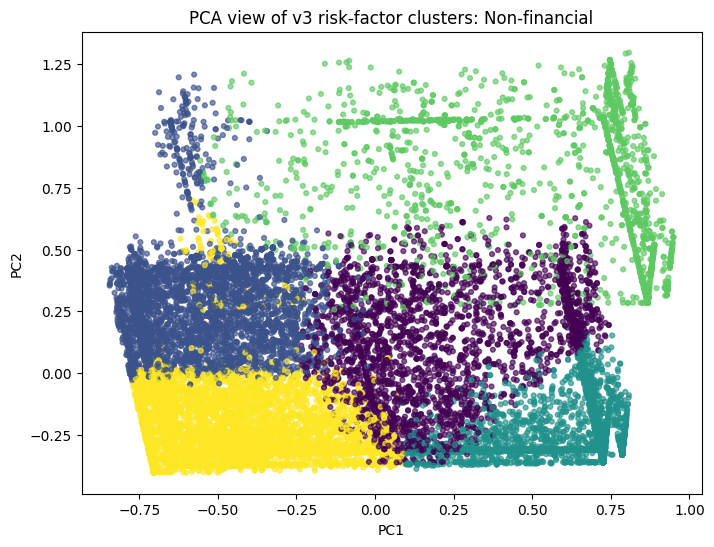

Explained variance: [0.5174765  0.21263547]


In [55]:
if not clustered_panel.empty:
    first_segment = clustered_panel[SEGMENT_COL].value_counts().index[0]
    g = clustered_panel[clustered_panel[SEGMENT_COL] == first_segment].copy()
    features = get_features_for_segment(first_segment, SEGMENT_COL)
    features = [f for f in features if f in g.columns and g[f].notna().any()]

    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    Xp = prep.fit_transform(g[features])
    pca = PCA(n_components=2, random_state=42)
    pcs = pca.fit_transform(Xp)

    plt.figure(figsize=(8, 6))
    plt.scatter(pcs[:, 0], pcs[:, 1], c=g["cluster"], s=12, alpha=0.65)
    plt.title(f"PCA view of v3 risk-factor clusters: {first_segment}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

    print("Explained variance:", pca.explained_variance_ratio_)


## 9. Compare 5 clusters vs alternatives

We want 5 clusters for business interpretability, but we should still test whether the data screams for fewer/more. Use this as governance, not as an automatic decision.

In [56]:
def evaluate_k_range(df, segment_name, segment_col, k_values=range(2, 9)):
    if CLUSTER_ONLY_SEGMENTS and segment_name not in CLUSTER_ONLY_SEGMENTS:
        return pd.DataFrame()

    requested_features = get_features_for_segment(segment_name, segment_col)
    use = df[df[segment_col] == segment_name].copy()
    features, availability = select_scorecard_features(
        use,
        requested_features,
        min_feature_coverage=0.0,
    )

    min_non_null_features = max(4, int(np.ceil(len(features) * 0.60)))
    if features:
        use = use[use[features].notna().sum(axis=1) >= min_non_null_features].copy()

    if len(use) < 500 or len(features) < 4:
        return pd.DataFrame()

    prep = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])
    X = prep.fit_transform(use[features])

    rows = []
    for k in k_values:
        labels = KMeans(n_clusters=k, init="k-means++", n_init=500, random_state=42).fit_predict(X)
        rows.append({
            "segment": segment_name,
            "k": k,
            "rows": len(use),
            "features": len(features),
            "feature_list": features,
            "silhouette": silhouette_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
        })
    return pd.DataFrame(rows)

k_tests = []
for segment_name in sorted(model_df[SEGMENT_COL].dropna().unique()):
    kt = evaluate_k_range(model_df, segment_name, SEGMENT_COL)
    if not kt.empty:
        k_tests.append(kt)

k_tests = pd.concat(k_tests, ignore_index=True) if k_tests else pd.DataFrame()
k_tests

,segment,k,rows,features,feature_list,silhouette,calinski_harabasz,davies_bouldin
0,Non-financial,2,21265,6,"[structural_distress_risk, earnings_risk, operating_cashflow_risk, liquidity_risk, leverage_risk, debt_service_risk]",0.425187,16391.559415,1.028255
1,Non-financial,3,21265,6,"[structural_distress_risk, earnings_risk, operating_cashflow_risk, liquidity_risk, leverage_risk, debt_service_risk]",0.454046,13982.735197,0.980583
2,Non-financial,4,21265,6,"[structural_distress_risk, earnings_risk, operating_cashflow_risk, liquidity_risk, leverage_risk, debt_service_risk]",0.394516,13121.530992,1.122005
3,Non-financial,5,21265,6,"[structural_distress_risk, earnings_risk, operating_cashflow_risk, liquidity_risk, leverage_risk, debt_service_risk]",0.372423,11785.252748,1.181313
4,Non-financial,6,21265,6,"[structural_distress_risk, earnings_risk, operating_cashflow_risk, liquidity_risk, leverage_risk, debt_service_risk]",0.382813,11172.007261,1.193365
5,Non-financial,7,21265,6,"[structural_distress_risk, earnings_risk, operating_cashflow_risk, liquidity_risk, leverage_risk, debt_service_risk]",0.395144,11126.225541,1.115100
6,Non-financial,8,21265,6,"[structural_distress_risk, earnings_risk, operating_cashflow_risk, liquidity_risk, leverage_risk, debt_service_risk]",0.406027,10644.632234,1.087782


## 10. Save outputs

These are the handoff files for review and downstream modeling.

In [62]:
current_path = OUTPUT_DIR / "credit_clustering_outputs_v3"
os.makedirs(current_path, exist_ok=True)

panel.to_parquet(os.path.join(current_path, "issuer_year_feature_panel_v3.parquet"), index=False)
clustered_panel.to_parquet(os.path.join(current_path, f"clustered_panel_v3_by_{SEGMENT_COL}.parquet"), index=False)
cluster_profile_ranked.to_csv(os.path.join(current_path, f"cluster_profile_v3_by_{SEGMENT_COL}.csv"), index=False)
metrics_df.to_csv(os.path.join(current_path, f"cluster_metrics_v3_by_{SEGMENT_COL}.csv"), index=False)
k_tests.to_csv(os.path.join(current_path, f"cluster_k_tests_v3_by_{SEGMENT_COL}.csv"), index=False)

print("Saved outputs to", current_path)

Saved outputs to D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\outputs\credit_clustering_outputs_v3


## Recommended next move

Run v3 and compare it to v2:

- v2 = peer financial-profile clustering.
- v3 = rating-style risk-factor clustering.

Expected difference:

- v2 may classify a profitable but liquidity-tight firm as a balanced operating issuer.
- v3 should push that same firm closer to a liquidity-constrained or elevated-risk bucket.

Governance check:

- The five v3 buckets should be ordered by median `scorecard_credit_score`.
- The distressed bucket should have high structural distress risk, high leverage risk, weak coverage, or negative equity.
- Size should be inspected only as a flag. If one risk bucket is mostly tiny firms, disclose it as a limitation.


In [61]:
if "Non-financial" not in segment_artifacts:
    raise ValueError("Non-financial segment artifact was not created. Check metrics_df and clustering setup.")

credit_cluster_artifact = {
    "model_name": "nonfinancial_credit_scorecard_kmeans_k5_v3",
    "version": "v3",
    "segment": "Non-financial",
    "pipeline": segment_artifacts["Non-financial"]["pipeline"],
    "feature_cols": segment_artifacts["Non-financial"]["feature_cols"],
    "cluster_labels": RATING_STYLE_LABELS_BY_CLUSTER,
    "risk_rank": RISK_RANK_BY_CLUSTER,
    "scorecard_thresholds": scorecard_thresholds,
    "scorecard_domain_weights": scorecard_domain_weights,
    "min_non_null_features": segment_artifacts["Non-financial"].get("min_non_null_features"),
    "scorecard_cluster_features": SCORECARD_CLUSTER_FEATURES,
    "scorecard_component_features": SCORECARD_COMPONENT_FEATURES,
    "ratio_cols": ratio_cols,
    "interpret_features": INTERPRET_FEATURES,
    "winsor_caps": winsor_caps,
    "training_rows": len(clustered_panel[clustered_panel["financial_flag"] == "Non-financial"]),
    "cluster_profile_ranked": cluster_profile_ranked,
    "metrics_df": metrics_df,
    "notes": (
        "V3 KMeans++ k=5 model trained on bounded directional credit-risk factors. "
        "Debt-service risk includes EBITDA-enhanced diagnostics where available, "
        "with legacy coverage/FCF fallback when EBITDA is unavailable. "
        "Absolute size is excluded from clustering and retained only as diagnostic flags. "
        "Labels are rating-style interpretations, not formal credit ratings."
    ),
}

output_path = MODEL_DIR / "nonfinancial_credit_scorecard_kmeans_k5_v3.joblib"
joblib.dump(credit_cluster_artifact, output_path)
print("Saved model to:", output_path)

Saved model to: D:\users\kamen.dimitrov\desktop\SOFTUNI\AI_and_ML_upskill_program\machine_learning\outputs\saved_models\nonfinancial_credit_scorecard_kmeans_k5_v3.joblib
